# Cardiac Patient Monitoring System

In this notebook, we load and inspect the Heart Disease dataset and prepare it for further analysis and machine learning.

## 1- Data Preparation




### 1. Import Libraries

We import Pandas and NumPy to load, inspect, and prepare the dataset.


In [1]:
import pandas as pd
import numpy as np

### Load Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\heart_disease_risk_2026.csv")

### Check Dataset

In [3]:
print(df.shape)

(9000, 27)


In [4]:
df.head(5)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [5]:
print(df.columns)

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='str')


In [6]:
df.dtypes

patient_id                     int64
age                            int64
sex                              str
resting_bp_systolic            int64
resting_bp_diastolic           int64
cholesterol_total              int64
hdl                            int64
ldl                            int64
triglycerides                  int64
fasting_blood_sugar            int64
hba1c                        float64
bmi                          float64
resting_heart_rate             int64
max_heart_rate_achieved        int64
chest_pain_type                  str
exercise_induced_angina         bool
st_depression                float64
family_history                  bool
smoker_status                    str
alcohol_units_per_week       float64
exercise_minutes_per_week      int64
sleep_hours                  float64
stress_score                 float64
wearable_owner                  bool
daily_steps                    int64
diet_quality_score           float64
has_heart_disease              int64
d

### Check Missing Values

In [7]:
df.isna().sum()

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

### check duplicate rows

In [8]:
df.duplicated().sum()

np.int64(0)

### check if the data set balanced or no

In [9]:
df['has_heart_disease'].value_counts()

has_heart_disease
0    6273
1    2727
Name: count, dtype: int64

### see if we have multiy values

In [10]:

print(df["chest_pain_type"].value_counts())
print(df["smoker_status"].value_counts())

chest_pain_type
Asymptomatic        4265
Non-Anginal Pain    2141
Atypical Angina     1576
Typical Angina      1018
Name: count, dtype: int64
smoker_status
Never      4980
Former     2448
Current    1572
Name: count, dtype: int64


we need onehotencoder for multiy values

### drop the id we don`t need it

In [11]:
df = df.drop("patient_id", axis=1)

### turn the boolain to numbers

In [12]:
bool_cols = [
    "exercise_induced_angina",
    "family_history",
    "wearable_owner"
]

df[bool_cols] = df[bool_cols].astype(int)

### statstic

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,9000.0,53.977333,13.008051,18.0,45.0,54.0,63.00,90.0
resting_bp_systolic,9000.0,127.849778,13.767233,85.0,119.0,128.0,137.00,181.0
resting_bp_diastolic,9000.0,80.788778,10.939943,50.0,74.0,81.0,88.00,126.0
cholesterol_total,9000.0,188.753556,32.271644,90.0,167.0,189.0,211.00,314.0
hdl,9000.0,55.215333,12.394400,18.0,47.0,55.0,64.00,110.0
ldl,9000.0,103.275556,27.342198,35.0,85.0,103.0,122.00,207.0
triglycerides,9000.0,152.045000,51.448384,35.0,117.0,151.0,186.00,390.0
fasting_blood_sugar,9000.0,119.470444,22.778082,60.0,104.0,119.0,135.00,204.0
hba1c,9000.0,5.791633,0.692645,4.0,5.3,5.8,6.30,8.6
bmi,9000.0,25.264922,4.371525,15.0,22.3,25.3,28.20,43.3


### check if wee have outliaers

those are potential outliers we will foucse in them more

In [14]:
num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols.drop([
    "exercise_induced_angina",
    "family_history",
    "wearable_owner",
    "has_heart_disease"
])
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = (
    (df[num_cols] < lower_bound) |(df[num_cols] > upper_bound)).sum()
print(outliers.sort_values(ascending=False))

st_depression                485
alcohol_units_per_week       431
sleep_hours                   86
resting_bp_diastolic          75
stress_score                  71
diet_quality_score            69
resting_bp_systolic           66
hdl                           63
cholesterol_total             50
resting_heart_rate            42
triglycerides                 42
bmi                           39
ldl                           34
daily_steps                   32
fasting_blood_sugar           32
exercise_minutes_per_week     27
max_heart_rate_achieved       17
hba1c                         10
age                            0
dtype: int64


## 2- EDA

### Target Distribution

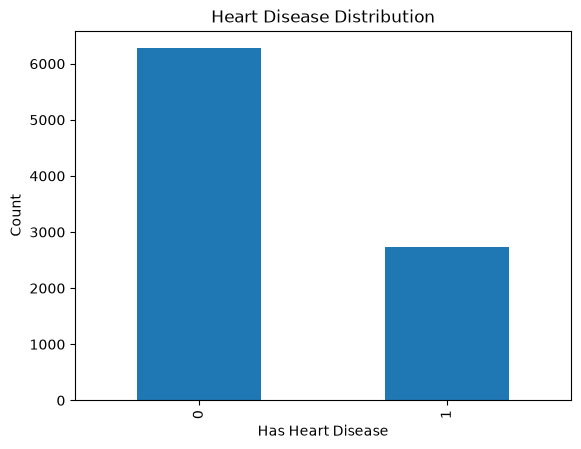

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

df["has_heart_disease"].value_counts().plot(
    kind="bar"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Has Heart Disease")
plt.ylabel("Count")
plt.show()



The target variable `has_heart_disease` is imbalanced.

- 69.7% of the observations belong to class 0 (No Heart Disease).
- 30.3% of the observations belong to class 1 (Heart Disease).

This indicates a moderate class imbalance, with class 0 being more frequent than class 1.

Therefore, model performance should not be evaluated using accuracy alone. Precision, recall, F1-score, and the confusion matrix will also be considered.

### Distribution of Cardiovascular Features

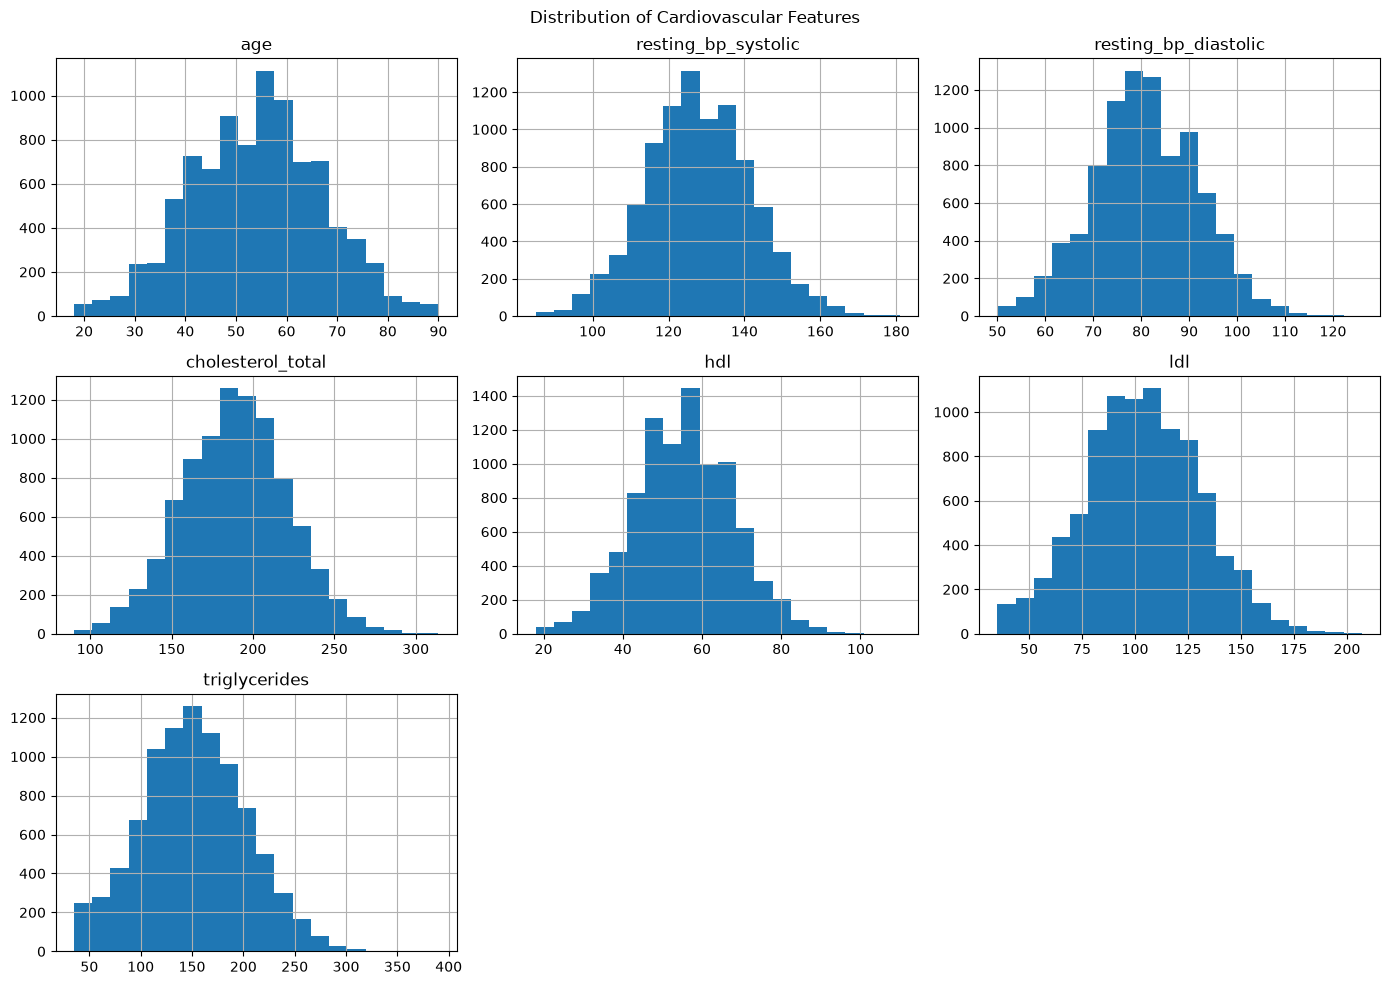

In [16]:
num_cols = [
    "age",
    "resting_bp_systolic",
    "resting_bp_diastolic",
    "cholesterol_total",
    "hdl",
    "ldl",
    "triglycerides"
]

df[num_cols].hist(
    bins=20,
    figsize=(14, 10)
)

plt.suptitle("Distribution of Cardiovascular Features")
plt.tight_layout()
plt.show()



The histograms show the distributions of selected cardiovascular features.

- Age is mainly concentrated around the middle age range.
- Resting systolic and diastolic blood pressure values are mostly concentrated around their central ranges.
- Total cholesterol, HDL, and LDL show relatively concentrated distributions with some observations in the upper ranges.
- Triglycerides show a wider spread compared with some of the other features.

These distributions help identify the central tendency, spread, skewness, and potential extreme observations before applying machine learning models.

### Distribution of Additional Patient Features

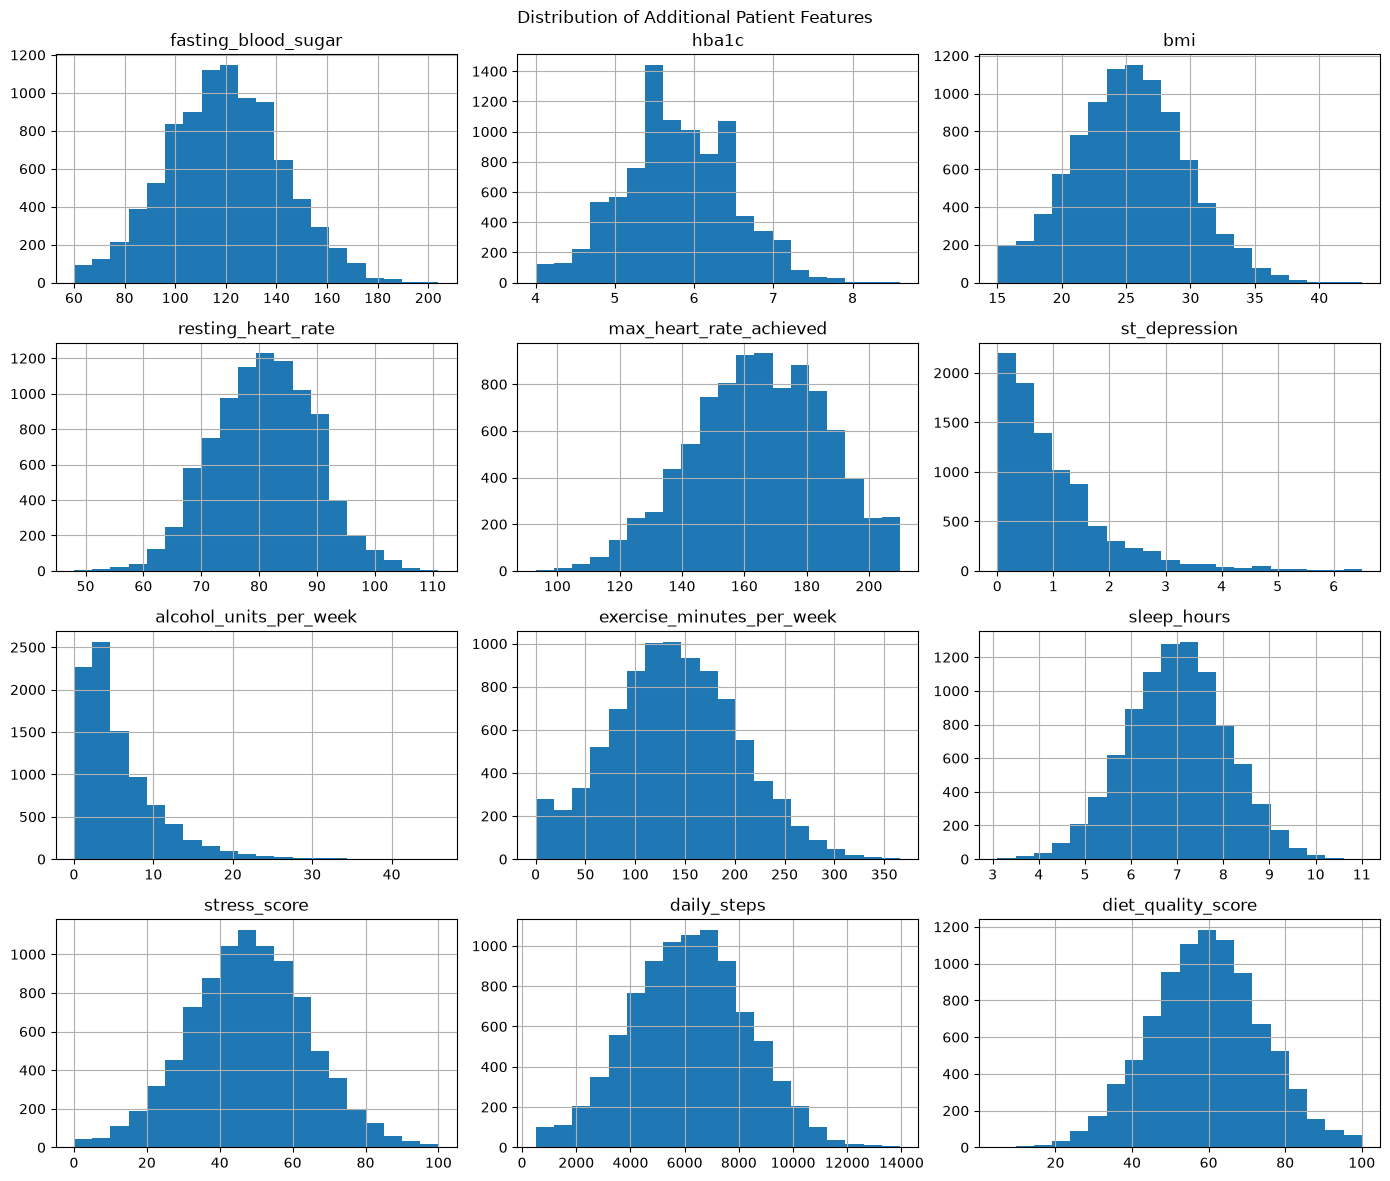

In [17]:
num_cols_2 = [
    "fasting_blood_sugar",
    "hba1c",
    "bmi",
    "resting_heart_rate",
    "max_heart_rate_achieved",
    "st_depression",
    "alcohol_units_per_week",
    "exercise_minutes_per_week",
    "sleep_hours",
    "stress_score",
    "daily_steps",
    "diet_quality_score"
]

df[num_cols_2].hist(
    bins=20,
    figsize=(14, 12)
)

plt.suptitle("Distribution of Additional Patient Features")
plt.tight_layout()
plt.show()



Most numerical features show approximately bell-shaped distributions centered around their typical values.

Some features, such as `st_depression` and `alcohol_units_per_week`, show right-skewed distributions, where most observations are concentrated at lower values with a smaller number of high-value observations.

These patterns are consistent with the outliers detected using the IQR method.

Understanding feature distributions helps identify skewness, variability, and potential extreme values before building machine learning models.

### Heart Disease by Sex

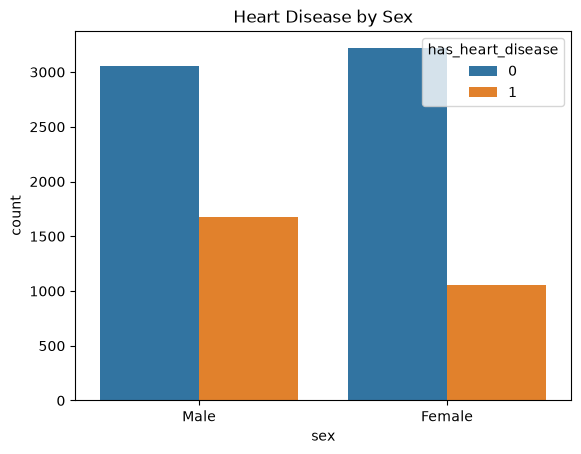

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(
    data=df,
    x="sex",
    hue="has_heart_disease"
)
plt.title("Heart Disease by Sex")
plt.show()


The count plot compares the number of patients with and without heart disease across male and female groups.
The number of observations is not the same for both sexes, so raw counts alone are not sufficient to compare the prevalence of heart disease between males and females.



### Heart Disease by Smoking Status

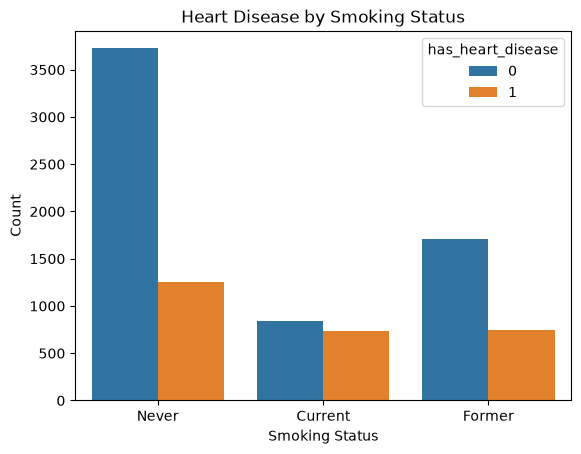

In [19]:
sns.countplot(
    data=df,
    x="smoker_status",
    hue="has_heart_disease"
)
plt.title("Heart Disease by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.show()


The count plot shows the distribution of heart disease across different smoking-status groups.

The plot compares patients with and without heart disease among never smokers, former smokers, and current smokers.

This visualization helps explore whether heart disease cases are distributed differently across smoking-status categories.

### Heart Disease by Chest Pain Type

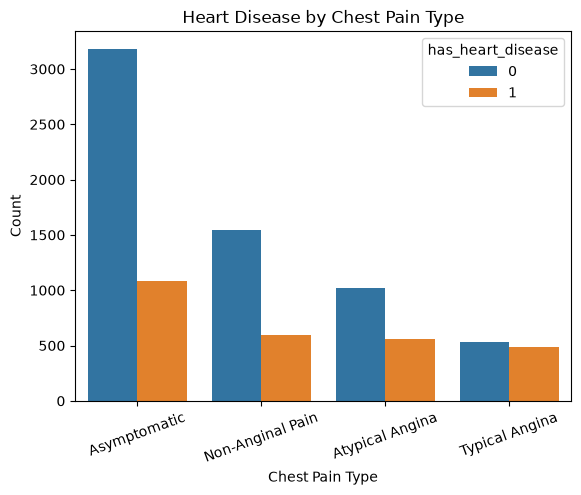

In [20]:
sns.countplot(
    data=df,
    x="chest_pain_type",
    hue="has_heart_disease"
)
plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


The count plot shows the distribution of heart disease across different chest pain types.

It compares patients with and without heart disease for Typical Angina, Atypical Angina, Non-Anginal Pain, and Asymptomatic chest pain.

This visualization helps identify differences in the distribution of heart disease across chest pain categories.

### Heart Disease by Family History

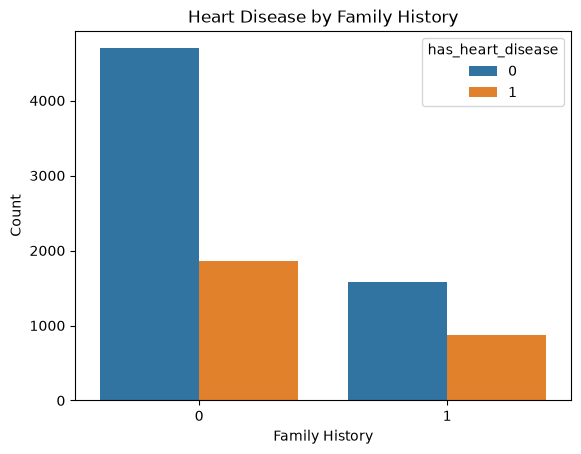

In [21]:
sns.countplot(
    data=df,
    x="family_history",
    hue="has_heart_disease"
)

plt.title("Heart Disease by Family History")
plt.xlabel("Family History")
plt.ylabel("Count")
plt.show()


The count plot shows the distribution of heart disease according to family history.

Patients are divided into two groups: those without a family history of heart disease and those with a family history.

The plot shows that the proportion of heart disease cases appears relatively higher in the family-history group

### Heart Disease by Exercise-Induced Angina

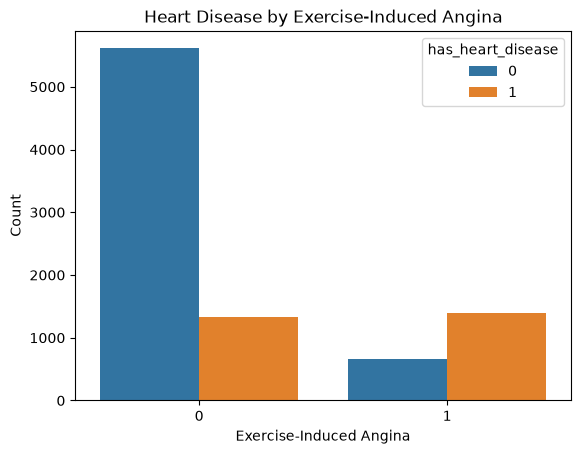

In [22]:
sns.countplot(
    data=df,
    x="exercise_induced_angina",
    hue="has_heart_disease"
)
plt.title("Heart Disease by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Count")
plt.show()


The count plot shows the distribution of heart disease according to exercise-induced angina.

Patients are divided into two groups: those without exercise-induced angina and those with exercise-induced angina.

The plot shows a noticeable difference in the distribution of heart disease between the two groups. Among patients with exercise-induced angina, the number of heart disease cases is higher than the number of patients without heart disease.

This suggests that exercise-induced angina may be an important feature for predicting heart disease.

### Correlation Analysis

In [23]:
corr = df.corr(numeric_only=True)

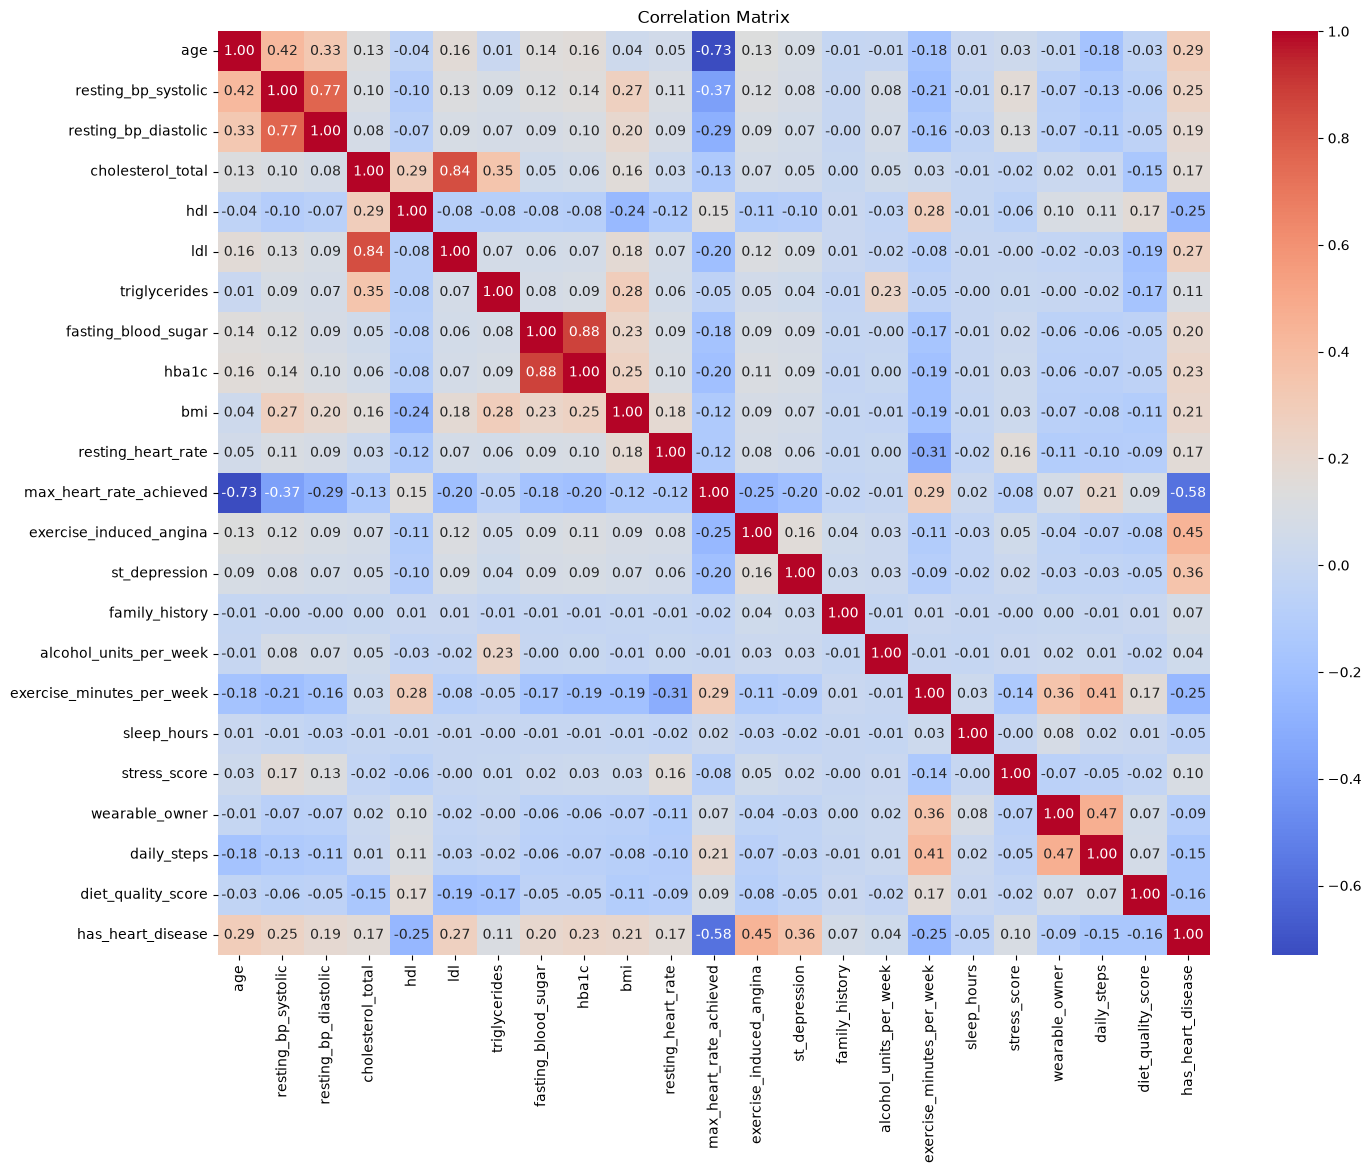

In [24]:
plt.figure(figsize=(16, 12))

sns.heatmap(corr, cmap="coolwarm",annot=True,fmt=".2f")

plt.title("Correlation Matrix")
plt.show()


The correlation matrix shows the linear relationships between the numerical features.

Some of the strongest relationships with `has_heart_disease` include:

- `max_heart_rate_achieved` has a negative correlation (-0.58).
- `exercise_induced_angina` has a positive correlation (0.45).
- `st_depression` has a positive correlation (0.36).
- `age` has a positive correlation (0.29).

Strong correlations also exist between some input features, such as `fasting_blood_sugar` and `hba1c` (0.88), and `cholesterol_total` and `ldl` (0.84).

Correlation describes linear relationships between variables but does not imply causation.

## 3- data Preprocessing

### Defining Features and Target

In [25]:
X = df.drop("has_heart_disease", axis=1)
y = df["has_heart_disease"]

### Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

### Identifying Numerical and Categorical Features

In [27]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

C:\Users\Hp\AppData\Local\Temp\ipykernel_23860\1280834089.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


### Building the Preprocessing Pipeline

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)